# Tarea 3: Modelos de difusión y flow matching
## MDS7203 Modelos Generativos Profundos
### Magíster en Ciencia de Datos - Universidad de Chile
#### Otoño, 2026

**Nombre:**

**Fecha de entrega:**

En esta tercera y última tarea se trabajará con [**Stable Diffusion 3**](https://arxiv.org/abs/2403.03206), el cual es un modelo text-to-image de tipo flow matching que utiliza una arquitectura MMDiT (DiT multimodal).

La tarea se divide en tres partes:

1. **Arquitectura del modelo:** se explorarán los componentes de la arquitectura MMDiT (sus text encoders, su mecanismo de atención y sus bloques) para entender cómo se procesan conjuntamente el texto y la imagen.
2. **Inferencia en flow matching:** se implementará el loop de generación desde cero, simulando la EDO de flow matching con el algoritmo de Euler y entendiendo las heurísticas adicionales que introduce Stable Diffusion 3 con respecto a la implementación vista en clases.
3. **DreamBooth:** se implementará la lógica de DreamBooth modificando manualmente el text encoder y usando LoRA para el fine-tuning.

**Instrucciones generales:**
- La tarea debe ejecutarse en **Google Colab con una GPU NVIDIA Tesla T4**.
- Se permite el uso libre de asistentes de IA (ChatGPT, Claude, Gemini, Copilot, etc.), pero **se debe entender en su totalidad el código entregado**.
- Se debe entregar este mismo `.ipynb` con todas las celdas ejecutadas.
- Las 3 partes de la tarea valen lo mismo (1/3 cada una).
- **Importante:** el notebook fue ejecutado en Google Colab, por lo que no es necesario cambiar los hiperparámetros asignados. Sin embargo, si se aumenta la cantidad de steps de generación o de entrenamiento, es posible obtener muchos mejores resultados a cambio de un mayor tiempo de ejecución (pero no de memoria GPU necesaria).

## Configuración inicial

Se comenzará instalando las librerías necesarias:

In [ ]:
!pip install -q "diffusers==0.32.2" "transformers==4.46.3" "peft>=0.13" "bitsandbytes>=0.44" accelerate sentencepiece protobuf matplotlib Pillow

La siguiente celda importa las librerías a utilizar. Se desactivan además las barras de progreso de Hugging Face para mantener las salidas del notebook limpias:

In [ ]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import gc
import glob
import textwrap
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
from huggingface_hub import login, snapshot_download
from peft import LoraConfig
from diffusers import BitsAndBytesConfig, SD3Transformer2DModel, StableDiffusion3Pipeline
from diffusers.utils import logging as diffusers_logging
from transformers import T5EncoderModel, BitsAndBytesConfig as BnbTransformers
from transformers.utils import logging as transformers_logging

diffusers_logging.set_verbosity_error()
diffusers_logging.disable_progress_bar()
transformers_logging.set_verbosity_error()
transformers_logging.disable_progress_bar()

La siguiente celda define el dispositivo a utilizar y algunas funciones auxiliares:

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

def free_memory() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def show_images(images: list[Image.Image], titles: list[str] | None = None, cols: int = 4) -> None:
    n = len(images)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(3.4 * cols, 3.7 * rows))
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')
        if titles is not None:
            plt.title(textwrap.fill(titles[i], 30), fontsize=8)
    plt.tight_layout()
    plt.show()

Dispositivo: cuda
GPU: Tesla T4


Stable Diffusion 3 es un gated model, por lo que se necesita aceptar su licencia en [Hugging Face](https://huggingface.co/stabilityai/stable-diffusion-3-medium) y utilizar el modelo usando un token con permiso de lectura:

In [ ]:
login(token='...')

La siguiente celda carga el pipeline de Stable Diffusion 3, el cual agrupa:
- **MMDiT:** red neuronal que aprende el campo de velocidades de flow matching.
- **Text encoders:** SD3 utiliza 3 text encoders (`CLIP-L`, `CLIP-G` y `T5-XXL`), cada uno con sus respectivos tokenizadores.
- **VAE:** como es usual, SD3 trabaja sobre el espacio latente de un VAE.
- **Scheduler:** análogo al scheduler de difusión, pero para flow matching.

Por limitaciones de memoria en Google Colab, el MMDiT y el modelo T5 se cargarán cuantizados a 4-bit usando `BitsAndBytes`.

In [ ]:
REPO = 'stabilityai/stable-diffusion-3-medium-diffusers'
nf4 = dict(load_in_4bit=True, bnb_4bit_quant_type='nf4', bnb_4bit_compute_dtype=torch.float16)

transformer = SD3Transformer2DModel.from_pretrained(
    REPO, subfolder='transformer', quantization_config=BitsAndBytesConfig(**nf4), torch_dtype=torch.float16)
text_encoder_3 = T5EncoderModel.from_pretrained(
    REPO, subfolder='text_encoder_3', quantization_config=BnbTransformers(**nf4), torch_dtype=torch.float16)

pipe = StableDiffusion3Pipeline.from_pretrained(
    REPO, transformer=transformer, text_encoder_3=text_encoder_3, torch_dtype=torch.float16)

pipe.text_encoder.to(DEVICE)
pipe.text_encoder_2.to(DEVICE)
pipe.vae.to(DEVICE)
pipe.set_progress_bar_config(disable=True)
vae = pipe.vae

In [ ]:
def count_params(model: torch.nn.Module) -> float:
    total = 0
    for p in model.parameters():
        n = p.numel()
        if p.__class__.__name__ == 'Params4bit':
            n *= 2
        total += n
    return total / 1e6

print(f'MMDiT (campo de velocidades): {count_params(transformer):.0f}M parámetros')
print(f'Text encoders: CLIP-L {count_params(pipe.text_encoder):.0f}M | CLIP-G {count_params(pipe.text_encoder_2):.0f}M | T5-XXL {count_params(text_encoder_3):.0f}M')
print(f'VAE: {count_params(vae):.0f}M parámetros')
print('Bloques MMDiT:', len(transformer.transformer_blocks), '| canales del espacio latente:', transformer.config.in_channels)

MMDiT (campo de velocidades): 2028M parámetros
Text encoders: CLIP-L 124M | CLIP-G 695M | T5-XXL 4762M
VAE: 84M parámetros
Bloques MMDiT: 24 | canales del espacio latente: 16


## Pregunta 1: Arquitectura MMDiT

Para comenzar, se estudiarán algunos aspectos de la red neuronal que utiliza SD3. El mayor cambio con respecto a la versión estudiada en clases (SD1) es que SD3 reemplaza la U-Net por un MMDiT (Multimodal Diffusion Transformer), el cual es una variante del DiT que permite condicionar con respecto a texto (recordar que el DiT original solo permite condicionar con respecto a una clase).

El siguiente diagrama, obtenido desde el [paper](https://arxiv.org/abs/2403.03206) de Stable Diffusion 3, resume esta arquitectura:

![MMDiT](mmdit.png)

La arquitectura MMDiT usada por SD3 tiene cuatro componentes clave:

- **Text encoders:** convierten el prompt en distintas representaciones (una secuencia de embeddings y un vector de embedding global).
- **Patchificación:** al igual que en DiT, se divide la representación latente de la imagen en patches y se proyecta a un espacio de tokens.
- **Embedding temporal:** combina el tiempo con el embedding global del texto, e inyecta esta condición mediante modulación adaLN (como en el DiT original).
- **Bloques MMDiT:** procesan conjuntamente los tokens de texto e imagen en un mecanismo de atención compartido.

A continuación se revisarán brevemente cada uno de estos componentes. El objetivo aquí es entender de manera general la arquitectura neuronal detrás de este modelo. Notar que esta arquitectura es agnóstica al tipo de entrenamiento (difusión o flow matching) ya que sirve para ambos casos.

Es importante mencionar que, si bien SD3 (comienzos de 2024) no fue tan popular como lo fue SD1 (finales de 2021) en su época, la arquitectura MMDiT utilizada refleja de manera cercana el tipo de arquitecturas que se utilizan en modelos más modernos (e.g. [Flux.1 Kontext](https://arxiv.org/abs/2506.15742), 2025). Sin embargo, muchos de los modelos top actuales son cerrados, por lo que no se conocen muchos detalles de sus implementaciones, mientras que los modelos open source actuales son demasiado pesados como para poder correrlos en una Tesla T4.

### Text encoders

SD3 usa tres text encoders complementarios, dos de tipo CLIP (`CLIP-L` y `CLIP-G`) y uno de tipo T5 (`T5-XXL`). Estos encoders permiten obtener dos representaciones del prompt dado para la generación condicional:

- Una secuencia de embeddings (un vector por token del prompt), formada al concatenar los embeddings de los dos CLIP (rellenados con ceros hasta la dimensión de T5) con los embeddings de T5, tal como muestra el panel izquierdo del diagrama de la arquitectura. Esta secuencia entra a los bloques del MMDiT como tokens de texto en el mecanismo de atención.
- Un embedding global del prompt (concatenación de los vectores globales de los dos CLIP) que resume el prompt en un solo vector y se usa para la modulación adaLN en los bloques Transformer del MMDiT.

Intuitivamente, los modelos CLIP permiten obtener una representación alineada con imágenes (útil para estilo y contenido global), mientras que el modelo T5 permite una comprensión más fina del lenguaje (útil para prompts largos y detallados).

> Codifique un prompt usando `pipe.encode_prompt` e indique el tamaño de los tensores asociados a la secuencia de tokens y al embedding global. Explique qué representa cada dimensión y en qué parte del MMDiT se utiliza cada uno. Para esto, puede basarse en el diagrama de arriba y/o explorar la clase de Python donde se implementa la arquitectura.

In [ ]:
prompt_embeds, _, pooled_embeds, _ = pipe.encode_prompt(
    prompt='a cat', prompt_2='a cat', prompt_3='a cat',
    do_classifier_free_guidance=True, device=DEVICE)ç


print('secuencia (prompt_embeds):', tuple(prompt_embeds.shape))
print('global (pooled_embeds):   ', tuple(pooled_embeds.shape))
print('dimensiones de los CLIP:', pipe.text_encoder.config.hidden_size, 'y', pipe.text_encoder_2.config.hidden_size)

secuencia (prompt_embeds): (1, 333, 4096)
global (pooled_embeds):    (1, 2048)
dimensiones de los CLIP: 768 y 1280


> **Respuesta:** La secuencia `prompt_embeds` tiene tamaño `(1, 333, 4096)`: contiene 333 tokens (77 de los CLIP concatenados más 256 de T5) y cada token se representa con un vector de dimensión 4096. Los embeddings de los CLIP tienen dimensión $768 + 1280 = 2048$, por lo que se rellenan con ceros hasta 4096 para poder concatenarlos con los de T5 a lo largo de la secuencia (esto corresponde al bloque gris del panel izquierdo del diagrama). El embedding global `pooled_embeds` tiene tamaño `(1, 2048)`: es un único vector por prompt, formado por la concatenación de los vectores globales de CLIP-L (768) y CLIP-G (1280). La secuencia entra a los bloques MMDiT como tokens de texto en la atención (previa proyección lineal), mientras que el embedding global se combina con el embedding del tiempo y modula las normalizaciones de los bloques (adaLN).

### Patchificación y embeddings de condición

Siguiendo el diagrama, la representación latente ruidosa se convierte en tokens de imagen mediante patchificación (módulo `pos_embed`, el cual además suma un embedding posicional), mientras que la secuencia de texto se proyecta a la dimensión interna del transformer (módulo `context_embedder`) y el tiempo se combina con el embedding global del texto (módulo `time_text_embed`) para producir el vector de condición $y$ que modula todos los bloques.

> Ejecute cada uno de estos tres módulos sobre entradas de prueba e indique los tamaños de sus salidas. Indique cuántos tokens de imagen se producen para una representación latente de resolución $64\times 64$ y explique de dónde sale ese número.

In [ ]:
latents = torch.randn(1, transformer.config.in_channels, 64, 64, device=DEVICE, dtype=torch.float16)
timestep = torch.tensor([500.0], device=DEVICE, dtype=torch.float16)

with torch.no_grad():
    tokens_img = transformer.pos_embed(latents)                   # patchificación + embedding posicional.
    tokens_txt = transformer.context_embedder(prompt_embeds)      # proyección de la secuencia de texto.
    y = transformer.time_text_embed(timestep, pooled_embeds)      # embedding de tiempo + embedding global.

print('tokens de imagen:', tuple(tokens_img.shape))
print('tokens de texto: ', tuple(tokens_txt.shape))
print('condición global y:', tuple(y.shape))
print('patch size:', transformer.config.patch_size)

tokens de imagen: (1, 1024, 1536)
tokens de texto:  (1, 333, 1536)
condición global y: (1, 1536)
patch size: 2


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


> **Respuesta:** La patchificación produce tokens de imagen de tamaño `(1, 1024, 1536)`: el latente de $64\times 64$ se divide en patches de $2\times 2$, produciendo $(64/2)\times(64/2) = 32\times 32 = 1024$ tokens, cada uno proyectado a la dimensión interna del transformer (1536). La secuencia de texto pasa de dimensión 4096 a 1536 mediante `context_embedder`, quedando de tamaño `(1, 333, 1536)`. Por último, `time_text_embed` codifica el tiempo con un embedding sinusoidal (como el estudiado en clases, en la unidad de LLMs y agentes), lo procesa con una MLP y le suma una proyección del embedding global del texto, produciendo el vector de condición $y$ de tamaño `(1, 1536)` que se usa para modular todos los bloques.

### Bloques MMDiT

El panel derecho del diagrama muestra un bloque MMDiT por dentro. De aquí se destacan 3 componentes:

1. **Dos streams modales separados:** cada bloque MMDiT procesa los tokens de texto $c$ y los tokens de imagen $x$ en dos ramas paralelas, cada una con sus propios parámetros (capas de normalización, proyecciones y MLPs). Esto se debe a que el texto y las imágenes son modalidades distintas, por lo que conviene que cada una aprenda sus propias transformaciones.

2. **Modulación adaLN:** el vector de condición $y$ descrito anteriormente (tiempo + embedding global del texto) no entra como un token más a los bloques MMDiT, sino que modula las activaciones de cada rama, igual que en la modulación realizada en el DiT original. Es decir, a partir del vector $y$ se calculan, vía una proyección lineal, los parámetros $\alpha, \beta, \gamma, \delta, \epsilon, \zeta$ del diagrama, los cuales escalan y desplazan las salidas de las normalizaciones (parámetros $\alpha, \beta$ antes de la atención y $\delta, \epsilon$ antes de la MLP) y escalan lo que se suma en las conexiones residuales (parámetros $\gamma$ y $\zeta$).

3. **Atención conjunta:** cada rama calcula sus propias proyecciones $Q, K, V$, pero luego estas se concatenan en una única secuencia antes de la atención. De este modo, los tokens de texto y los tokens de imagen se atienden mutuamente en una sola operación de self-attention.

> Ejecute un bloque MMDiT (`transformer_blocks`) sobre los tokens y vector de condición obtenido en la sección anterior, y verifique que las salidas mantienen los tamaños de entrada de cada stream. Además, inspeccione el módulo de atención del bloque y liste sus proyecciones lineales. Luego, identifique para qué se utiliza cada una.

In [ ]:
block = transformer.transformer_blocks[0]

with torch.no_grad():
    tokens_txt_out, tokens_img_out = block(hidden_states=tokens_img, encoder_hidden_states=tokens_txt, temb=y)

print('salida stream imagen:', tuple(tokens_img_out.shape))
print('salida stream texto: ', tuple(tokens_txt_out.shape))

proyecciones = [n for n, m in block.attn.named_modules() if isinstance(m, torch.nn.Linear)]
print('proyecciones de la atención:', proyecciones)

salida stream imagen: (1, 1024, 1536)
salida stream texto:  (1, 333, 1536)
proyecciones de la atención: ['to_q', 'to_k', 'to_v', 'add_k_proj', 'add_v_proj', 'add_q_proj', 'to_out.0', 'to_add_out']


> **Respuesta:** El bloque recibe y devuelve los dos streams con sus tamaños intactos: `(1, 1024, 1536)` para la imagen y `(1, 333, 1536)` para el texto (además recibe el vector de condición $y$, que alimenta las modulaciones). La atención tiene ocho proyecciones lineales, organizadas en dos grupos. Para el stream de imagen: `to_q`, `to_k` y `to_v` generan las matrices $Q, K, V$ de los tokens de imagen, y `to_out.0` es la proyección de salida que se aplica sobre la parte de la atención correspondiente a la imagen. Para el stream de texto: `add_q_proj`, `add_k_proj` y `add_v_proj` generan los $Q, K, V$ de los tokens de texto, y `to_add_out` es su respectiva proyección de salida. Los $Q, K, V$ de ambos streams se concatenan y se realiza una única self-attention sobre la secuencia combinada de $1024 + 333$ tokens; luego cada stream recupera su parte de la salida y la proyecta con su propia capa de salida.

## Pregunta 2: Inferencia en flow matching

En esta pregunta se implementará el loop de generación desde cero. Recordar que en flow matching (caso incondicional) la red neuronal entrenada aprende el campo de velocidades $\tilde u_t(x_t)$ que transporta una distribución inicial $p_0(x_0) = p_\text{prior}(x_0)$ hacia $p_1(x_1) = p_\text{data}(x_1)$, por lo que la generación consiste en simular la EDO

$$
\begin{cases}
\dot x_t = u_t^\theta(x_t) \\
x_0 \sim p_\text{prior}(x_0)
\end{cases}
$$

desde $t=0$ hasta $t=1$, donde $u_t^\theta \approx \tilde u_t$ es la red neuronal entrenada. Para esta simulación, SD3 sigue la misma lógica que la implementación vista en clases, pero introduce algunas convenciones y heurísticas adicionales que se revisarán a lo largo de la tarea.

La primera convención es temporal: SD3 hereda de los modelos de difusión y rectified flows el tiempo invertido, por lo que su tiempo $t$ corresponde a $1-t$ según la notación vista en clases (que es la estándar de flow matching). De este modo, $t=1$ corresponde a ruido puro, $t=0$ a la imagen limpia, y las trayectorias son $x_t = (1-t)\,x_1 + t\,x_0$ (con $x_1$ la imagen original y $x_0$ el ruido gaussiano).

Bajo esta convención, la red de SD3 no aprende el campo $\tilde u$ de clases sino su negativo, $v_t(x_t) := x_0 - x_1 = -\tilde u(x_t)$, ya que al recorrer el tiempo al revés las velocidades cambian de signo. La generación consiste entonces en simular la misma EDO anterior (con $v_t^\theta$ en lugar de $u_t^\theta$), ahora comenzando desde ruido puro en $t=1$ y avanzando hacia $t=0$ (i.e., con pasos $\Delta t < 0$). En lo que sigue se usará siempre la convención de SD3.

### Classifier-free guidance

En clases se estudió la técnica de classifier-free guidance (CFG) para modelos de difusión, la cual induce al modelo a darle más importancia al prompt. Esta técnica se construyó a partir de la formulación score-based de los modelos de difusión, y luego se mostró que podía aplicarse a otras formulaciones equivalentes (e.g., $\epsilon$-prediction o $x_0$-prediction). Para flow matching se puede demostrar que el campo de velocidades es una transformación afín de la función score, por lo que se puede aplicar la misma técnica de guidance usada en modelos de difusión. En este caso, para un prompt $y$, si $\varnothing$ es el prompt vacío y $s$ el guidance scale, se puede considerar el campo de velocidades corregido

$$
\tilde v_t = v_t^\theta(x \mid \varnothing) + s\,\big(v_t^\theta(x \mid y) - v_t^\theta(x \mid \varnothing)\big)
$$

Considerando lo mencionado anteriormente, se definirán tres funciones auxiliares para la inferencia con SD3:

- `encode_text`: codifica el prompt y el prompt vacío (negative prompt) necesario para CFG.
- `predict_velocity`: evalúa el MMDiT y retorna el campo de velocidades (con corrección de guidance aplicada si $s \neq 1$).
- `decode_latents`: genera una imagen a partir de una representación latente (obtenida mediante la simulación de la EDO) usando el decoder del VAE.

> Implemente la función `predict_velocity`. Considere que el embedding temporal de la red neuronal de SD3 fue entrenado recibiendo $1000\,t$ en vez de $t \in [0, 1]$ directamente (herencia de los 1000 pasos del modelo DDPM original), por lo que se debe considerar esta amplificación en la implementación.

In [ ]:
@torch.no_grad()
def encode_text(prompt: str, negative: str = '') -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    emb, neg_emb, pooled, neg_pooled = pipe.encode_prompt(
        prompt=prompt, prompt_2=prompt, prompt_3=prompt,
        negative_prompt=negative, do_classifier_free_guidance=True, device=DEVICE,
    )
    return emb, pooled, neg_emb, neg_pooled

def predict_velocity(latents: torch.Tensor, t: torch.Tensor, text: tuple, guidance: float) -> torch.Tensor:
    emb, pooled, neg_emb, neg_pooled = text
    timestep = (t * 1000.0).to(latents.dtype).expand(latents.shape[0])

    def call(e: torch.Tensor, p: torch.Tensor) -> torch.Tensor:
        return transformer(hidden_states=latents, encoder_hidden_states=e,
                           pooled_projections=p, timestep=timestep, return_dict=False)[0]

    v_cond = call(emb, pooled)
    if guidance == 1.0:
        return v_cond
    v_uncond = call(neg_emb, neg_pooled)
    return v_uncond + guidance * (v_cond - v_uncond)

@torch.no_grad()
def decode_latents(latents: torch.Tensor) -> list[Image.Image]:
    latents = latents.to(vae.dtype) / vae.config.scaling_factor + vae.config.shift_factor
    image = vae.decode(latents, return_dict=False)[0]
    return pipe.image_processor.postprocess(image, output_type='pil')

### Algoritmo de Euler y time shift

Para simular la EDO con el algoritmo de Euler se debe particionar el intervalo de simulación, $[0, 1]$. Si bien en clases se utilizó una partición uniforme, no todos los tramos de la simulación aportan lo mismo en la simulación, lo cual se vuelve notorio en la generación de imágenes. En particular, los primeros pasos ($t\approx 1$) son los que definen la estructura global de la imagen, mientras que los últimos ($t\approx 0$) solo refinan detalles que ya fueron más o menos definidos a lo largo de la simulación. Por lo tanto, con un budget limitado de pasos (e.g. 20) conviene colocar más puntos de la partición en la zona de ruido alto, y menos donde la imagen ya está casi resuelta. Además, el paper de SD3 considera que, al aumentar la resolución, un mismo nivel de ruido destruye proporcionalmente menos información (una imagen de mayor resolución tiene más redundancia), por lo que en resoluciones altas conviene sesgar aún más la partición hacia el ruido alto.

SD3 implementa esta idea manteniendo el algoritmo de Euler intacto y cambiando únicamente la partición. Más precisamente, cada punto de la partición uniforme $t_i = 1 - i/N$ se desplaza aplicando la transformación

$$
\text{shift}(t) = \frac{m\,t}{1 + (m-1)\,t},
$$

donde $m > 0$ es un hiperparámetro ($m = 3$ en SD3). Para $m > 1$ esta función es cóncava y empuja los puntos hacia $t = 1$, dejando la partición más concentrada en la zona de ruido alto y más dispersa cerca de la imagen final (con $m = 1$ se recupera la partición uniforme). Esta partición desplazada es exactamente la que implementa el scheduler del pipeline (`FlowMatchEulerDiscreteScheduler`), pero aquí se implementará manualmente.

La siguiente celda grafica la transformación para distintos valores de $m$, junto con la partición que produce para $N = 12$ pasos. Notar cómo, partiendo de una partición uniforme en el eje horizontal, los tiempos resultantes quedan concentrados cerca de $t = 1$:

shift del scheduler: 3.0


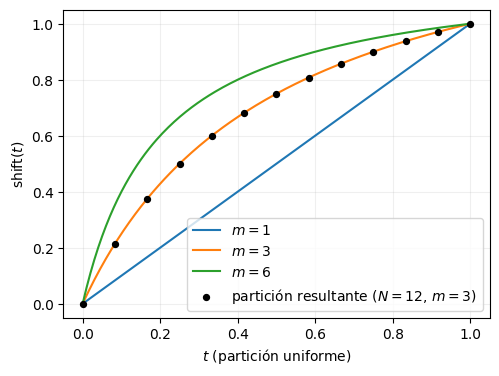

In [ ]:
shift = pipe.scheduler.config.shift
print('shift del scheduler:', shift)

def shifted_times(num_steps: int, m: float) -> torch.Tensor:
    t = torch.linspace(1, 0, num_steps + 1)
    return m * t / (1 + (m - 1) * t)

t = torch.linspace(0, 1, 200)
plt.figure(figsize=(5.5, 4))
for m in [1.0, 3.0, 6.0]:
    plt.plot(t, m * t / (1 + (m - 1) * t), label=f'$m = {m:g}$')

plt.scatter(torch.linspace(1, 0, 13), shifted_times(12, shift), color='black', zorder=3, s=18,
            label=f'partición resultante ($N=12$, $m={shift:g}$)')

plt.xlabel(r'$t$ (partición uniforme)')
plt.ylabel(r'$\mathrm{shift}(t)$')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Luego, con la partición $1 = t_0 > t_1 > \cdots > t_N = 0$ definida, y recordando que el tiempo está invertido, el algoritmo de Euler toma la forma

$$
x_{t_{i+1}} = x_{t_i} + (t_{i+1} - t_i)\,v_{t_i}^\theta(x_{t_i})
$$

> Implemente la función `euler_sample`, la cual debe generar una imagen a partir de un prompt simulando la EDO de flow matching con el algoritmo de Euler. La función implementada debe:
> - Construir la partición desplazada con `shifted_times`.
> - Inicializar la representación latente como ruido gaussiano (recordar que $t_0 = 1$ corresponde a ruido puro).
> - Iterar el algoritmo de Euler usando `predict_velocity`.
> - Decodificar la representación latente final con `decode_latents`.

In [ ]:
@torch.no_grad()
def euler_sample(prompt: str, num_steps: int = 28, guidance: float = 4.5,
                 seed: int = 0, m: float | None = None) -> list[Image.Image]:
    text = encode_text(prompt)
    times = shifted_times(num_steps, m if m is not None else shift).to(DEVICE)

    generator = torch.Generator(DEVICE).manual_seed(seed)
    latents = torch.randn(1, transformer.config.in_channels, 64, 64,
                          generator=generator, device=DEVICE, dtype=torch.float16)

    for i in range(num_steps):
        v = predict_velocity(latents, times[i], text, guidance)
        latents = latents + (times[i + 1] - times[i]) * v

    return decode_latents(latents)

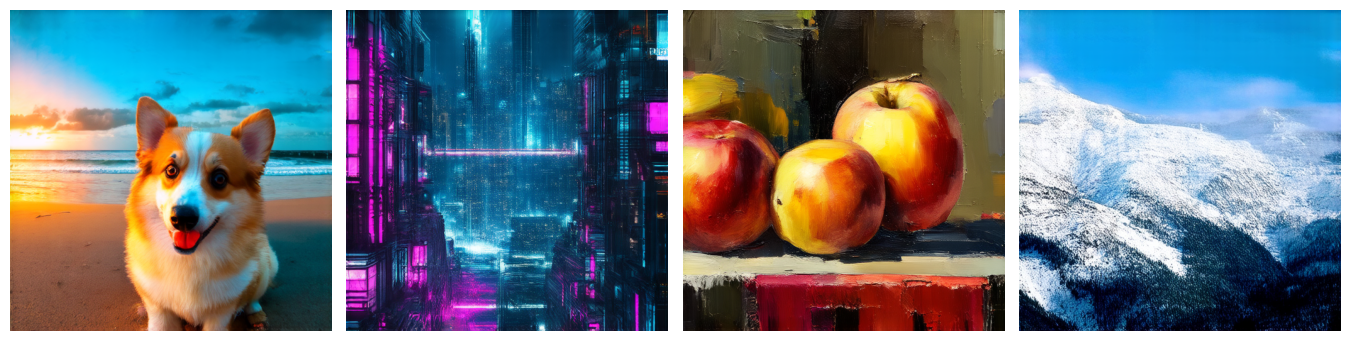

In [ ]:
prompts = [
    'a cute corgi sitting on a beach at sunset, highly detailed',
    'a futuristic city with neon lights, cyberpunk',
    'a still life painting of fruits, oil on canvas',
    'a photograph of a snowy mountain landscape',
]
images = [euler_sample(p, num_steps=20, seed=0)[0] for p in prompts]
show_images(images)

Para ver el efecto de la heurística del time shift, se generará la misma imagen (mismo prompt y semilla) con pocos pasos en el algoritmo de Euler, primero con la partición uniforme ($m=1$) y luego con la partición desplazada del modelo ($m=3$).

> Genere una imagen con `num_steps=6` usando $m=1$ y $m=3$, y comente las diferencias observadas. ¿Por qué la diferencia se nota más con pocos pasos que con muchos?

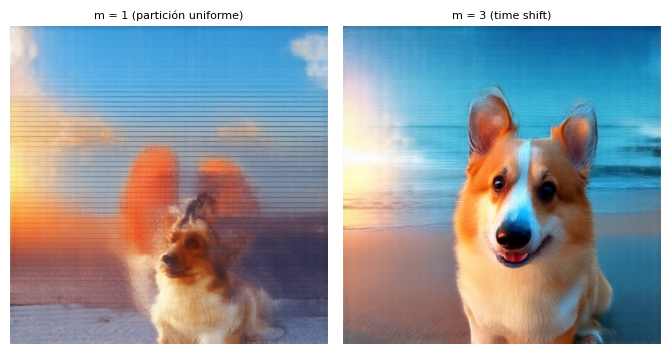

In [ ]:
prompt = 'a cute corgi sitting on a beach at sunset, highly detailed'
img_uniforme = euler_sample(prompt, num_steps=6, seed=0, m=1.0)[0]
img_shift = euler_sample(prompt, num_steps=6, seed=0, m=3.0)[0]
show_images([img_uniforme, img_shift], titles=['m = 1 (partición uniforme)', 'm = 3 (time shift)'], cols=2)

> **Respuesta:** Con 6 pasos, la partición uniforme dedica muy pocas evaluaciones a la zona de ruido alto, que es donde se define la estructura global de la imagen: el resultado queda difuso y lavado, con el sujeto y el fondo mal resueltos. Con $m=3$ la partición concentra los pasos en esa zona y, con el mismo presupuesto de evaluaciones, la imagen resulta nítida y bien compuesta. Con muchos pasos la diferencia se atenúa, ya que ambas particiones se vuelven suficientemente finas en todas las zonas: el error de discretización de Euler es pequeño en cualquier caso y la ubicación exacta de los puntos deja de ser crítica.

Por otro lado, para ver la necesidad de CFG, se generará la misma imagen (mismo prompt y semilla) con distintos valores de guidance scale.

> Genere una imagen con $s \in \{1,\ 4.5,\ 9\}$ y comente el efecto de la escala de guidance sobre la muestra.

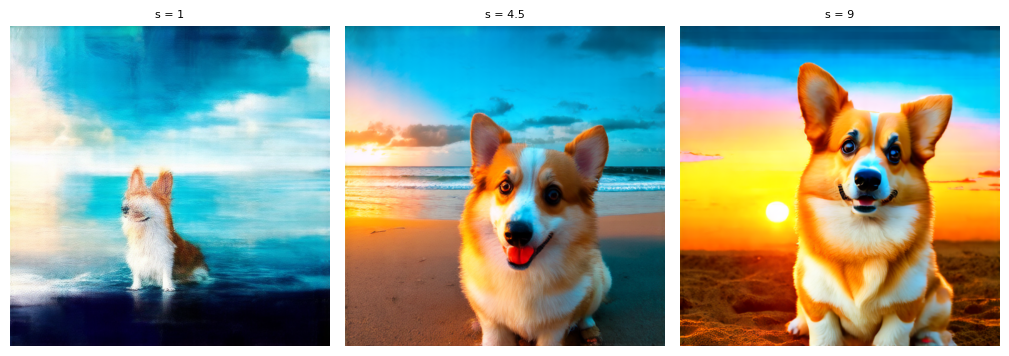

In [ ]:
prompt = 'a cute corgi sitting on a beach at sunset, highly detailed'
scales = [1.0, 4.5, 9.0]
imgs_cfg = [euler_sample(prompt, num_steps=20, seed=0, guidance=s)[0] for s in scales]
show_images(imgs_cfg, titles=[f's = {s:g}' for s in scales], cols=3)

> **Respuesta:** Sin guidance ($s=1$) la muestra es notoriamente peor: más difusa, con menos detalle y con menor adherencia al prompt, ya que la predicción condicional por sí sola no basta para alinear la generación con la descripción. Con $s=4.5$ la imagen es nítida y fiel al prompt: la extrapolación amplifica la dirección en que el prompt modifica el campo de velocidades. Con $s=9$ la fidelidad se mantiene, pero la imagen tiende a sobresaturarse y perder naturalidad (colores y contrastes exagerados), el costo usual de un guidance excesivo. Esto muestra que CFG es necesario para obtener muestras de calidad, y que la escala tiene un punto óptimo intermedio.

## Pregunta 3: DreamBooth + LoRA

Como se vio en clases, DreamBooth permite enseñarle a un modelo tipo text-to-image un concepto nuevo (e.g. un objeto específico) a partir de pocas imágenes, asociándole un identificador (uno o más tokens poco frecuentes), y haciendo fine-tuning del modelo completo. Para que el fine-tuning sea liviano, aquí se implementará DreamBooth usando LoRA sobre el MMDiT, manteniendo el resto del modelo congelado.

### Datos de entrenamiento

Como datos de entrenamiento se utilizará un conjunto de imágenes usado en el [paper original](https://arxiv.org/abs/2208.12242) de DreamBooth (con resize a $512\times 512$):

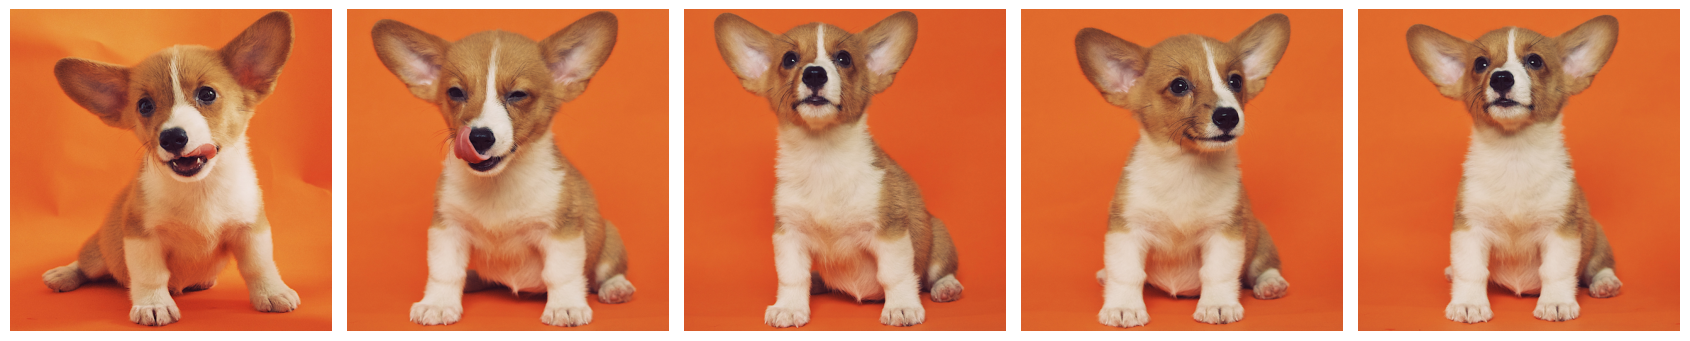

In [ ]:
data_dir = snapshot_download('diffusers/dog-example', repo_type='dataset')
paths = sorted(glob.glob(data_dir + '/*.jpeg') + glob.glob(data_dir + '/*.jpg') + glob.glob(data_dir + '/*.png'))
instance_images = [Image.open(p).convert('RGB').resize((512, 512), Image.BICUBIC) for p in paths]
show_images(instance_images, cols=len(instance_images))

### Modificación del text encoder

Para poder utilizar DreamBooth es necesario uno o más tokens que representen al sujeto dentro de los prompts (identificador). El paper original reutiliza como identificador un token poco frecuente que ya existe en el vocabulario (usualmente `<sks>`). El problema práctico de esa elección es que un token existente puede arrastrar significados aprendidos durante el preentrenamiento, además de que un string arbitrario puede tokenizarse en varias subpalabras.

Aquí se pedirá implementar una combinación de las dos técnicas vistas en clases. De Textual Inversion se utilizará la mecánica para crear el identificador agregando un token nuevo al vocabulario de los tokenizadores, cuyo embedding se creará expandiendo la matriz de embeddings de los text encoders, inicializando el embedding con el embedding de la palabra de clase ("dog") para que el identificador comience representando un perro genérico. Sin embargo, a diferencia de Textual Inversion, donde el nuevo embedding es el único parámetro que se entrena y el modelo completo queda congelado, aquí el embedding se mantendrá congelado y lo que se ajustará, al igual que en DreamBooth, será el modelo generativo (vía LoRA sobre el MMDiT). Es decir, el token nuevo actuará únicamente como un nombre fijo para el sujeto, y la red neuronal del MMDiT será la que aprenda qué generar cuando ese nombre aparezca en el prompt. Notar que el prompt es procesado por los dos CLIPs y el modelo T5, por lo que la modificación se debe aplicar a los dos tokenizadores CLIP con sus respectivos encoders (para T5 no es será necesario ya que su tokenizador maneja tokens fuera de vocabulario).

De este modo, el prompt de entrenamiento será `a photo of a <sks> dog`, donde `dog` es la clase del sujeto y `<sks>` es el identificador a especializar.

▎ Implemente la función `add_identifier_token`, la cual debe agregar el token indentificador a los dos tokenizadores CLIP, redimensionar las matrices de embeddings de sus text encoders e inicializar el embedding del nuevo token con el promedio de los embeddings de los tokens de `class_word`.

In [ ]:
def add_identifier_token(identifier: str, class_word: str) -> None:
    for tokenizer, encoder in [(pipe.tokenizer, pipe.text_encoder), (pipe.tokenizer_2, pipe.text_encoder_2)]:
        tokenizer.add_tokens(identifier)
        encoder.resize_token_embeddings(len(tokenizer))
        embeddings = encoder.get_input_embeddings().weight.data
        class_ids = tokenizer(class_word, add_special_tokens=False).input_ids
        new_id = tokenizer.convert_tokens_to_ids(identifier)
        embeddings[new_id] = embeddings[class_ids].mean(dim=0)


add_identifier_token('<sks>', 'dog')
instance_prompt = 'a photo of a <sks> dog'
print('Prompt de instancia:', instance_prompt)

Prompt de instancia: a photo of a <sks> dog


### Precómputo de embeddings

Como el sujeto se describe siempre con el mismo prompt y son pocas imágenes, conviene precomputar una única vez las representaciones latentes de las imágenes (usando el encoder del VAE) y los embeddings del prompt de instancia (usando los text encoders modificados):

In [ ]:
@torch.no_grad()
def encode_images(images: list[Image.Image]) -> torch.Tensor:
    pixel_values = pipe.image_processor.preprocess(images).to(DEVICE, dtype=vae.dtype)
    latents = vae.encode(pixel_values).latent_dist.sample()
    return ((latents - vae.config.shift_factor) * vae.config.scaling_factor).to(torch.float16)


instance_latents = encode_images(instance_images)
emb, pooled, _, _ = encode_text(instance_prompt)
print('Representaciones latentes de imagen:', tuple(instance_latents.shape))
print('Embeddings de prompt:', tuple(emb.shape))
free_memory()

Representaciones latentes de imagen: (5, 16, 64, 64)
Embeddings de prompt: (1, 333, 4096)


### Función objetivo

Si bien SD3 se presenta como un modelo de tipo rectified flow, esta técnica es equivalente a flow matching con la elección de hiperparámetros vista en clases, $\alpha_t = t$ y $\beta_t = 1-t$, la cual genera las trayectorias condicionales $x_t = t\,x_1 + (1-t)\,x_0$. Estas trayectorias son rectas que unen $x_0$ y $x_1$ (de ahí el nombre de rectified flow) siguiendo un campo de velocidades condicional $\tilde u_t(x_t | x_1) = x_1 - x_0$ constante en el tiempo. El hecho de que estas trayectorias sean rectas ayuda a que la simulación con el algoritmo de Euler funcione bien con pocos pasos.

En consecuencia, el fine-tuning sobre SD3 utiliza la misma función objetivo vista en clases (escrita con la convención temporal de SD3), donde en el caso de DreamBooth y Textual Inversion es usual considerar siempre el mismo prompt sobre el dataset de entrenamiento. Luego, la función objetivo a implementar es

$$
\mathcal{L}(\theta) = \mathbb{E}_{t,\, x_1 \sim p_\text{data}(x_1),\, x_0 \sim \mathcal{N}(0, \text{I})}\left[\left\| v_t^\theta\big((1-t)\,x_1 + t\,x_0 \mid \texttt{"a photo of a <sks> dog"}\big) - (x_0 - x_1) \right\|^2\right],
$$

donde $p_\text{data}(x_1)$ representa, abusando de notación, la distribución de las imágenes luego de pasar por el encoder del VAE.

Por otro lado, otra heurística que incluye SD3 es no muestrear el tiempo de forma uniforme, $t \sim \text{Uniforme}([0,1])$, sino usar una versión ponderada, $t = \text{sigmoid}(z)$ con $z \sim \mathcal{N}(0,1)$ (i.e., $t$ sigue una distribución logit-normal). La intuición detrás de esta elección es que los extremos son poco informativos. En efecto, con $t \approx 0$ la entrada es casi la imagen limpia y predecir la velocidad es fácil, mientras que con $t \approx 1$ la entrada es casi ruido puro y la mejor predicción posible casi no depende de la entrada. SD3 observa que los niveles intermedios son los más difíciles de aprender (y donde más importa la calidad de la predicción), por lo que propone muestrearlos con mayor frecuencia durante el entrenamiento. La siguiente celda compara el peso que cada distribución le asigna a los distintos niveles de ruido:

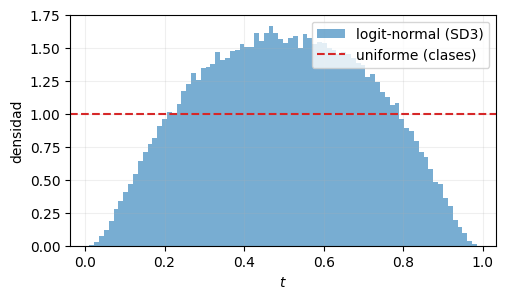

In [ ]:
t = torch.sigmoid(torch.randn(100_000))

plt.figure(figsize=(5.5, 3))
plt.hist(t.numpy(), bins=80, density=True, alpha=0.6, label='logit-normal (SD3)')
plt.axhline(1.0, color='C3', linestyle='--', label='uniforme (clases)')
plt.xlabel(r'$t$')
plt.ylabel('densidad')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Fine-tuning usando LoRA

Para realizar un entrenamiento más eficiente, se utilizará LoRA sobre las proyecciones de atención del MMDiT (en ambos streams) usando `peft`, y solo esos parámetros quedarán entrenables. Notar que el modelo base está cuantizado, por lo que esta configuración corresponde a QLoRA (visto en la tarea 2). Además, el entrenamiento se realizará en precisión mixta, donde los parámetros de LoRA se mantendrán en float32 (entrenar en float16 produce overflow y NaN), y el forward se ejecutará en float16. Además, un `GradScaler` reescalará la loss para evitar underflow en los gradientes.

In [ ]:
lora_config = LoraConfig(
    r=16, lora_alpha=16, init_lora_weights='gaussian',
    target_modules=['to_q', 'to_k', 'to_v', 'to_out.0', 'add_q_proj', 'add_k_proj', 'add_v_proj', 'to_add_out'],
)
transformer.add_adapter(lora_config)
for p in transformer.parameters():
    if p.requires_grad:
        p.data = p.data.float()
trainable = [p for p in transformer.parameters() if p.requires_grad]
print(f'Parámetros entrenables (LoRA): {sum(p.numel() for p in trainable)/1e6:.2f}M')

Parámetros entrenables (LoRA): 9.39M


> Implemente la función `train_dreambooth`, la cual debe hacer fine-tuning (usando LoRA) con la función objetivo definida anteriormente. Recordar que en cada iteración debe:
> - Obtener un batch de representaciones latentes $x_1 \sim p_\text{data}(x_1)$.
> - Generar un batch de ruido $x_0 \sim \mathcal{N}(0, \text{I})$ y un batch de tiempos $t$ logit-normales (uno por imagen).
> - Calcular $x_t = (1-t)\,x_1 + t\,x_0$ y evaluar el MMDiT con el prompt asociado a la instancia.
> - Evaluar la función objetivo y hacer un step de optimización.

In [ ]:
def train_dreambooth(steps: int = 1000, batch_size: int = 4, lr: float = 1e-4) -> list[float]:
    optimizer = torch.optim.AdamW(trainable, lr=lr)
    scaler = torch.amp.GradScaler('cuda')
    transformer.train()
    n = instance_latents.shape[0]
    history = []

    for step in range(steps):
        idx = torch.randint(0, n, (batch_size,))
        x1 = instance_latents[idx]
        x0 = torch.randn_like(x1)
        t = torch.sigmoid(torch.randn(batch_size, 1, 1, 1, device=DEVICE, dtype=x1.dtype))
        x_t = (1 - t) * x1 + t * x0
        timestep = (t.flatten() * 1000.0).to(x1.dtype)

        with torch.autocast('cuda', dtype=torch.float16):
            v_pred = transformer(
                hidden_states=x_t, encoder_hidden_states=emb.expand(batch_size, -1, -1),
                pooled_projections=pooled.expand(batch_size, -1), timestep=timestep, return_dict=False)[0]
        loss = F.mse_loss(v_pred.float(), (x0 - x1).float())

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        history.append(loss.item())

        if (step + 1) % 100 == 0:
            print(f'paso {step + 1}/{steps} | pérdida (promedio últimos 100): {np.mean(history[-100:]):.4f}')

    transformer.eval()
    for p in trainable:
        p.data = p.data.half()
    return history

In [ ]:
del prompt_embeds, pooled_embeds, tokens_img, tokens_txt, latents
free_memory()

history = train_dreambooth(steps=500, batch_size=1, lr=1e-4)
free_memory()

paso 100/400 | pérdida (promedio últimos 100): 0.1852
paso 200/400 | pérdida (promedio últimos 100): 0.1753
paso 300/400 | pérdida (promedio últimos 100): 0.1499
paso 400/400 | pérdida (promedio últimos 100): 0.1620


La siguiente celda grafica la función de pérdida durante el fine-tuning. Notar que la pérdida por paso es muy ruidosa, lo cual es esperable ya que en cada paso se elige un nivel de ruido $t$, un ruido $x_0$ y una imagen de entrenamiento distinta. Superponiendo una EMA sobre estos valores se puede ver de mejor manera la tendencia del entrenamiento:

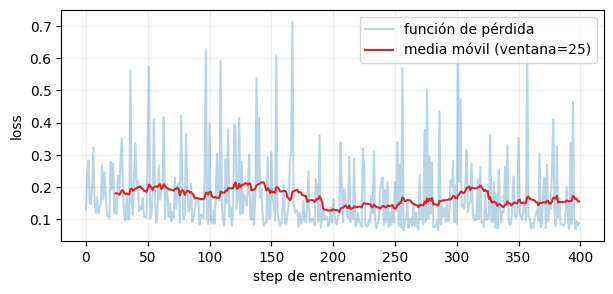

In [ ]:
history = np.array(history)
window = 25
smooth = np.convolve(history, np.ones(window) / window, mode='valid')

plt.figure(figsize=(7, 3))
plt.plot(history, alpha=0.3, label='función de pérdida')
plt.plot(range(window - 1, len(history)), smooth, color='C3', label=f'media móvil (ventana={window})')
plt.xlabel('step de entrenamiento')
plt.ylabel('loss')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Inferencia

Con el modelo fine-tuned, el MMDiT debería asociar el identificador `<sks>` al sujeto presentado durante el entrenamiento.

> Genere imágenes del sujeto en distintos contextos usando el identificador `<sks>` y comente si el modelo logró aprender el concepto. Reutilice la función `euler_sample` de la pregunta anterior, incluyendo `<sks>` en los prompts.

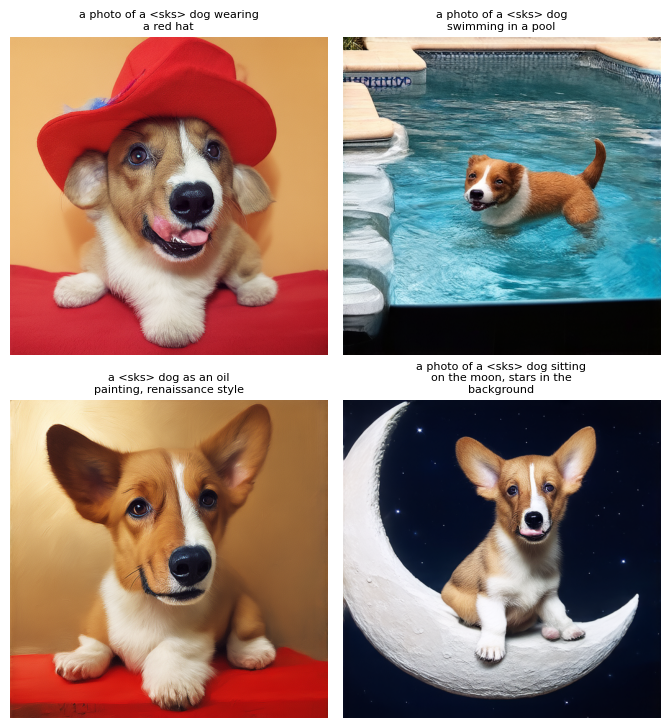

In [ ]:
personalized_prompts = [
    'a photo of a <sks> dog wearing a red hat',
    'a photo of a <sks> dog swimming in a pool',
    'a <sks> dog as an oil painting, renaissance style',
    'a photo of a <sks> dog sitting on the moon, stars in the background',
]
generated = [euler_sample(p, num_steps=20, seed=0)[0] for p in personalized_prompts]
show_images(generated, titles=personalized_prompts, cols=2)

> **Respuesta:** Las imágenes generadas preservan la identidad del perro de las fotos de entrenamiento (raza, colores y rasgos) al usar el identificador `<sks>`, adaptándola a los contextos pedidos. Esto muestra que basta una LoRA sobre el campo de velocidades, sin modificar los pesos originales del modelo ni el embedding del identificador, para ligar el concepto nuevo al token `<sks>`.